# Solcent — Exploratory Data Analysis (pre-preprocessing)

**Goal:** understand the *raw* joined dataset and let the data tell us what preprocessing
it needs — **we do not trim, impute, or modify anything here**. Every cleaning decision
later should point back to a plot or number in this notebook.

Dataset: `solcent_dataset.csv` (hourly, 2024–2026), produced by `build_daily_blocks.py`.
- target: `load_factor` (= measured / monitoredcapacity, 0–1)
- weather features: Open-Meteo *Previous Runs* (day-ahead lead) for ECMWF / ICON / GFS
- Elia's own `dayaheadforecast` (+ confidence10/90) = the baseline to beat


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

DATA = "../data/processed/solcent_dataset.csv"    # <-- edit if your file lives elsewhere
df = pd.read_csv(DATA, index_col=0, parse_dates=True).sort_index()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

21,168 rows x 60 columns


,measured,dayaheadforecast,dayaheadconfidence10,dayaheadconfidence90,monitoredcapacity,load_factor,shortwave_radiation_previous_day1_ecmwf,shortwave_radiation_previous_day2_ecmwf,direct_radiation_previous_day1_ecmwf,direct_radiation_previous_day2_ecmwf,...,cloud_cover_low_previous_day1_gfs,cloud_cover_low_previous_day2_gfs,cloud_cover_mid_previous_day1_gfs,cloud_cover_mid_previous_day2_gfs,cloud_cover_high_previous_day1_gfs,cloud_cover_high_previous_day2_gfs,temperature_2m_previous_day1_gfs,temperature_2m_previous_day2_gfs,wind_speed_10m_previous_day1_gfs,wind_speed_10m_previous_day2_gfs
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,8788.791,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,8788.791,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,8788.791,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Integrity — is the time axis sound?
Check the span, whether every hour is present (no missing rows), duplicates, and dtypes.

In [2]:
print("range :", df.index.min(), "->", df.index.max())
print("tz    :", df.index.tz)
full = pd.date_range(df.index.min(), df.index.max(), freq="1h", tz=df.index.tz)
print(f"expected hourly rows: {len(full):,} | actual: {len(df):,} | MISSING ROWS: {len(full)-len(df)}")
print("duplicated timestamps:", int(df.index.duplicated().sum()))
print("\ndtypes:\n", df.dtypes.value_counts())

range : 2024-01-01 00:00:00+00:00 -> 2026-05-31 23:00:00+00:00
tz    : UTC
expected hourly rows: 21,168 | actual: 21,168 | MISSING ROWS: 0
duplicated timestamps: 0

dtypes:
 float64    60
Name: count, dtype: int64


## 1b. Column inventory — what's actually here (and the cloud naming)

60 columns is a lot to eyeball. This groups every weather column by **family / lead / model**
so it's obvious which columns exist and which are empty. In particular it clears up the cloud
confusion: the **total** cloud cover is stored as `cloud_cover_previous_day{1,2}_{model}`, while
the empty ones are the **layered** `cloud_cover_low/mid/high_*` fields.

In [3]:
import re
def family(c):
    m = re.match(r"(.+?)_previous_day(\d)_(\w+)$", c)
    return (m.group(1), f"day{m.group(2)}", m.group(3)) if m else (c, "", "")

inv = pd.DataFrame([dict(column=c, family=family(c)[0], lead=family(c)[1],
                         model=family(c)[2], pct_missing=round(df[c].isna().mean()*100, 1))
                    for c in df.columns])
weather = inv[inv.model != ""]

print("Non-null hours by weather family x model (0 = dead column):")
grid = weather.assign(nonnull=lambda x: [int(df[c].notna().sum()) for c in x.column])
print(grid.pivot_table(index="family", columns="model", values="nonnull", aggfunc="max").to_string())

print("\n>>> TOTAL cloud cover (this IS your cloud column — keep):")
print(weather[weather.family == "cloud_cover"][["column", "pct_missing"]].to_string(index=False))
print("\n>>> LAYERED cloud (low/mid/high — all empty — drop):")
lay = weather[weather.family.isin(["cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"])]
print(f"{len(lay)} columns, all {lay.pct_missing.min():.0f}-{lay.pct_missing.max():.0f}% missing")

Non-null hours by weather family x model (0 = dead column):
model                ecmwf    gfs   icon
family                                  
cloud_cover          20352  20724  20724
cloud_cover_high         0      0      0
cloud_cover_low          0      0      0
cloud_cover_mid          0      0      0
diffuse_radiation    19591  20724  20724
direct_radiation     19591  20724  20724
shortwave_radiation  19591  20724  20724
temperature_2m       20352  20724  20724
wind_speed_10m       20352  20724  20724

>>> TOTAL cloud cover (this IS your cloud column — keep):
                         column  pct_missing
cloud_cover_previous_day1_ecmwf          3.9
cloud_cover_previous_day2_ecmwf          4.0
 cloud_cover_previous_day1_icon          2.1
 cloud_cover_previous_day2_icon          2.2
  cloud_cover_previous_day1_gfs          2.1
  cloud_cover_previous_day2_gfs          2.2

>>> LAYERED cloud (low/mid/high — all empty — drop):
18 columns, all 100-100% missing


## 2. Missingness — the headline question

Three views:
1. overall % missing per column,
2. which columns are **completely** empty,
3. **missingness over time** (a heatmap of day × column) — this reveals whether gaps are a
   start-up ramp, scattered dropouts, or whole dead columns.

Columns with ANY missing values: 54


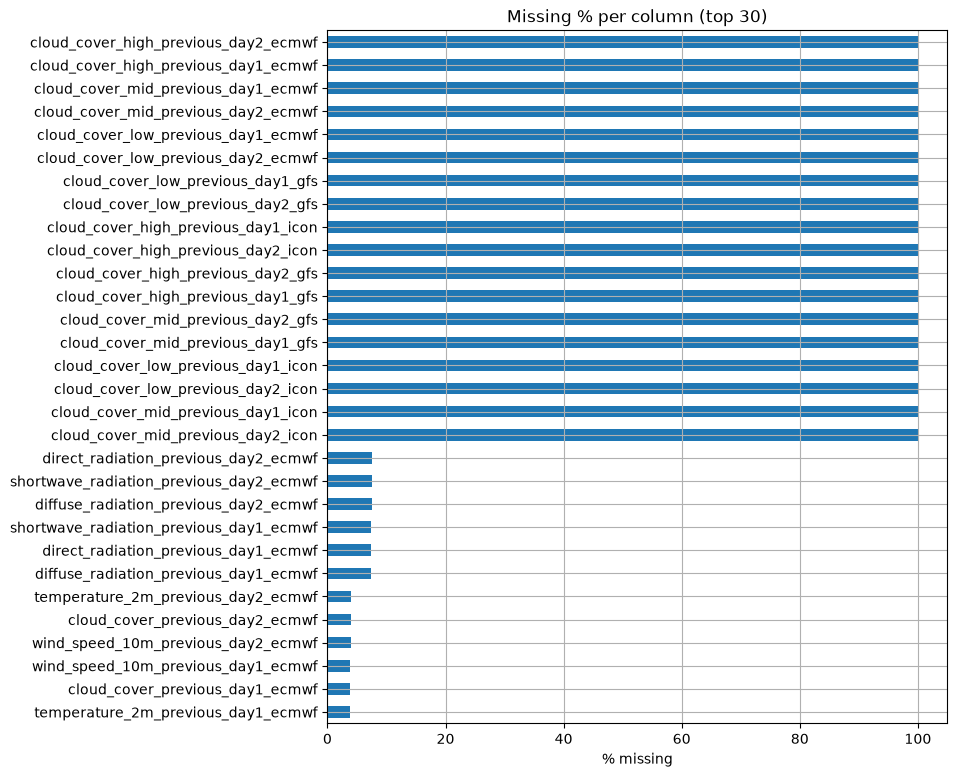

In [4]:
miss = (df.isna().mean()*100).round(1)
miss_nonzero = miss[miss > 0].sort_values(ascending=False)
print("Columns with ANY missing values:", len(miss_nonzero))
ax = miss_nonzero.head(30).iloc[::-1].plot.barh(figsize=(8, 9))
ax.set_xlabel("% missing"); ax.set_title("Missing % per column (top 30)")
plt.show()

In [5]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
print(f"FULLY EMPTY columns ({len(empty_cols)}):")
for c in empty_cols:
    print("  ", c)

FULLY EMPTY columns (18):
   cloud_cover_low_previous_day1_ecmwf
   cloud_cover_low_previous_day2_ecmwf
   cloud_cover_mid_previous_day1_ecmwf
   cloud_cover_mid_previous_day2_ecmwf
   cloud_cover_high_previous_day1_ecmwf
   cloud_cover_high_previous_day2_ecmwf
   cloud_cover_low_previous_day1_icon
   cloud_cover_low_previous_day2_icon
   cloud_cover_mid_previous_day1_icon
   cloud_cover_mid_previous_day2_icon
   cloud_cover_high_previous_day1_icon
   cloud_cover_high_previous_day2_icon
   cloud_cover_low_previous_day1_gfs
   cloud_cover_low_previous_day2_gfs
   cloud_cover_mid_previous_day1_gfs
   cloud_cover_mid_previous_day2_gfs
   cloud_cover_high_previous_day1_gfs
   cloud_cover_high_previous_day2_gfs


C:\Users\rdip2\AppData\Local\Temp\ipykernel_27008\709763250.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = daily_miss.index.to_period("M").astype(str)


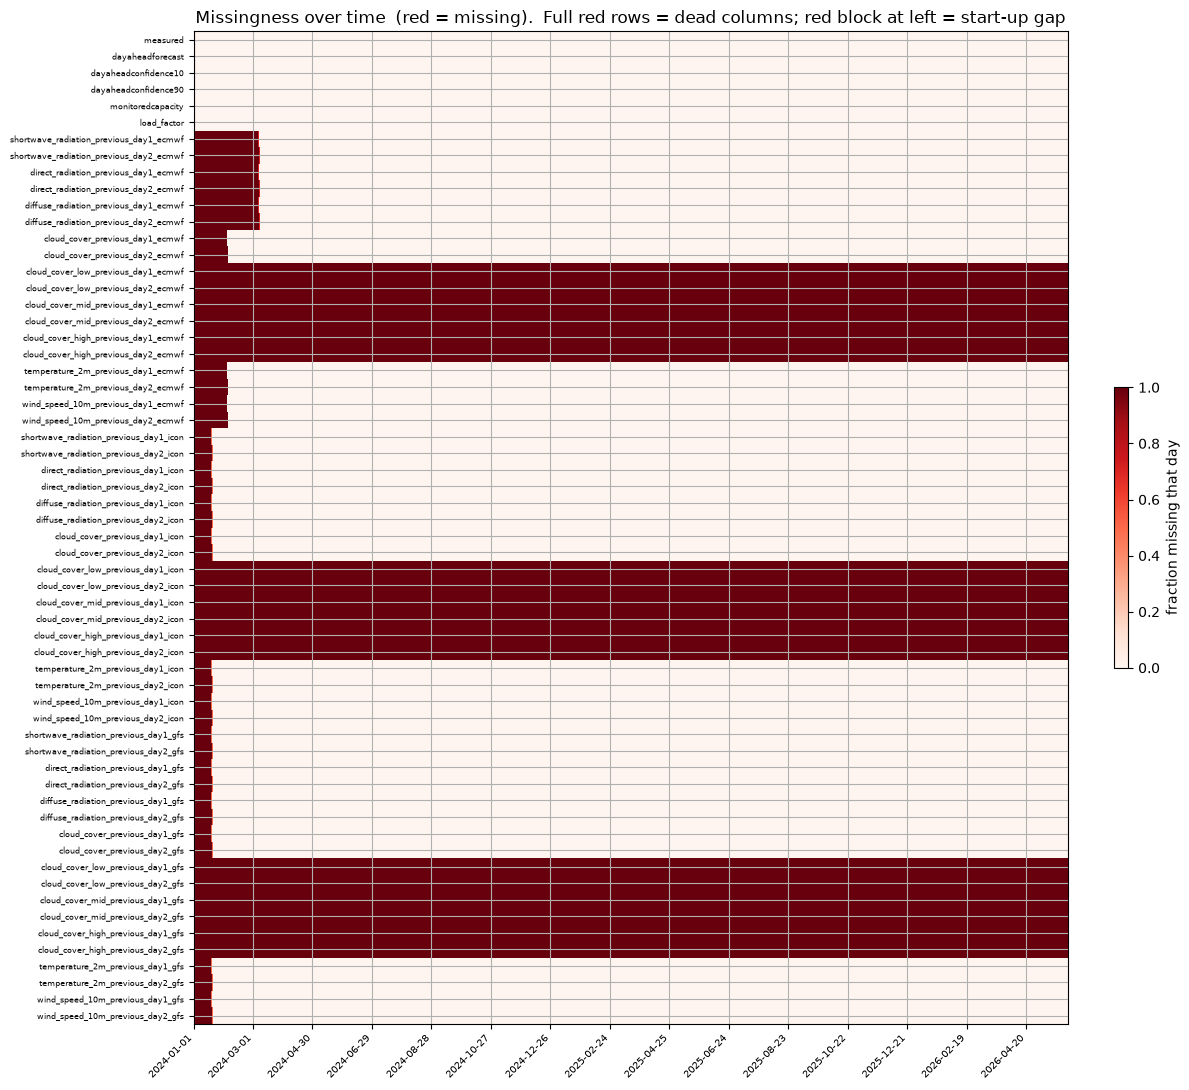

In [6]:
# Missingness over time: fraction missing per DAY for each column (downsampled view)
daily_miss = df.isna().resample("1D").mean()
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(daily_miss.T.values, aspect="auto", cmap="Reds", vmin=0, vmax=1,
               extent=[0, len(daily_miss), len(df.columns), 0], interpolation="nearest")
ax.set_yticks(np.arange(len(df.columns)) + 0.5)
ax.set_yticklabels(df.columns, fontsize=6)
# x ticks as month labels
months = daily_miss.index.to_period("M").astype(str)
tick_pos = [i for i in range(0, len(daily_miss), 60)]
ax.set_xticks(tick_pos); ax.set_xticklabels([str(daily_miss.index[i].date()) for i in tick_pos], rotation=45, ha="right", fontsize=7)
ax.set_title("Missingness over time  (red = missing).  Full red rows = dead columns; red block at left = start-up gap")
fig.colorbar(im, ax=ax, fraction=0.015, label="fraction missing that day")
plt.tight_layout(); plt.show()

**Read the heatmap:** solid horizontal red stripes are columns that are *always* missing
(dead features). A red block confined to the **left edge** is a start-up gap at the
beginning of the time range — fixable by choosing a later start date, not by imputation.

In [7]:
# Quantify the start-up gap: monthly missing % for one GHI column per model
probe = {m: f"shortwave_radiation_previous_day1_{m}" for m in ["ecmwf","icon","gfs"]}
probe = {m: c for m, c in probe.items() if c in df.columns}
mm = pd.DataFrame({m: df[c].isna() for m, c in probe.items()})
by_month = (mm.groupby(mm.index.to_period("M")).mean()*100).round(0)
nz = by_month[(by_month.T != 0).any()]
print("Months where GHI is missing for any model (% missing):")
print(nz.to_string())

Months where GHI is missing for any model (% missing):
              ecmwf  icon   gfs
datetime_utc                   
2024-01       100.0  60.0  60.0
2024-02       100.0   0.0   0.0
2024-03        18.0   0.0   0.0


C:\Users\rdip2\AppData\Local\Temp\ipykernel_27008\460834644.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = (mm.groupby(mm.index.to_period("M")).mean()*100).round(0)


## 3. The target — is what we predict intact?
`measured`, `load_factor`, `dayaheadforecast`, `monitoredcapacity` must be clean. Then look
at the shape of the target (expect a big spike at 0 from night) and check for impossible
values (negative, or load factor > 1).

In [8]:
core = ["measured","dayaheadforecast","dayaheadconfidence10","dayaheadconfidence90",
        "monitoredcapacity","load_factor"]
print("Missing % in core/target columns:")
print((df[core].isna().mean()*100).round(2).to_string())
print("\nload_factor describe:")
print(df["load_factor"].describe().round(3).to_string())
print("\nSanity flags:")
print("  negative load_factor:", int((df["load_factor"] < 0).sum()))
print("  load_factor > 1     :", int((df["load_factor"] > 1).sum()))
print("  negative measured   :", int((df["measured"] < 0).sum()))

Missing % in core/target columns:
measured                0.0
dayaheadforecast        0.0
dayaheadconfidence10    0.0
dayaheadconfidence90    0.0
monitoredcapacity       0.0
load_factor             0.0

load_factor describe:
count    21168.000
mean         0.102
std          0.162
min          0.000
25%          0.000
50%          0.002
75%          0.151
max          0.751

Sanity flags:
  negative load_factor: 0
  load_factor > 1     : 0
  negative measured   : 0


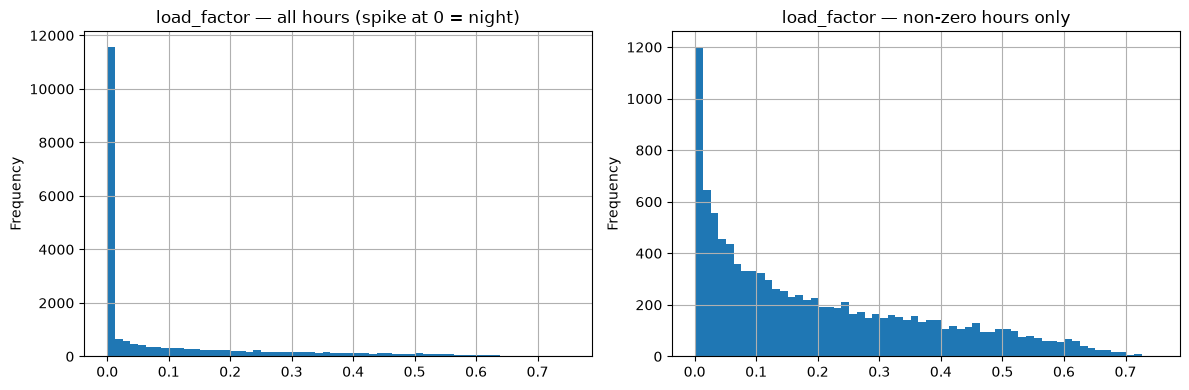

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["load_factor"].plot.hist(bins=60, ax=ax[0]); ax[0].set_title("load_factor — all hours (spike at 0 = night)")
df[df["load_factor"] > 0.001]["load_factor"].plot.hist(bins=60, ax=ax[1]); ax[1].set_title("load_factor — non-zero hours only")
plt.tight_layout(); plt.show()

## 4. Non-stationarity — does installed capacity drift?
A growing fleet is why we predict *load factor* (normalized) rather than raw MW. Look for
the upward trend and any sudden steps/revisions.

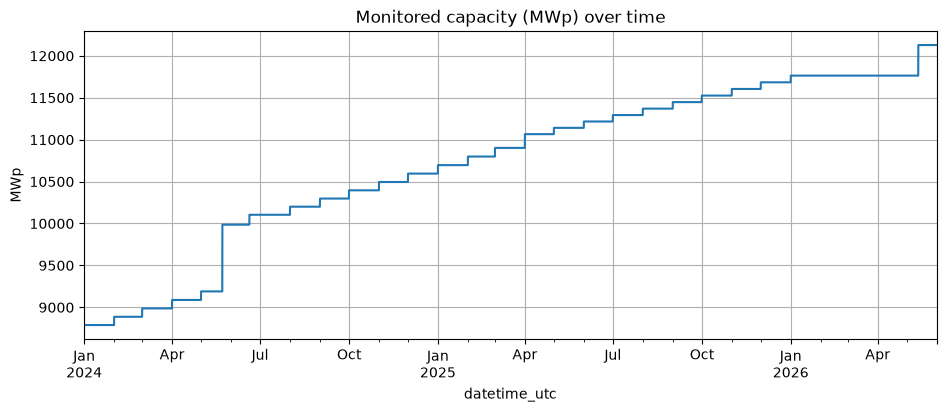

capacity range (MWp): 8789 -> 12128   (+38%)


In [10]:
ax = df["monitoredcapacity"].plot(title="Monitored capacity (MWp) over time")
ax.set_ylabel("MWp"); plt.show()
print("capacity range (MWp):", round(df['monitoredcapacity'].min()), "->", round(df['monitoredcapacity'].max()),
      f"  (+{100*(df['monitoredcapacity'].max()/df['monitoredcapacity'].min()-1):.0f}%)")

## 5. Diurnal & seasonal structure
Mean load factor by hour and by month, plus an hour×month heatmap — this is the seasonal
shape the model must learn, and it confirms you have all seasons covered.

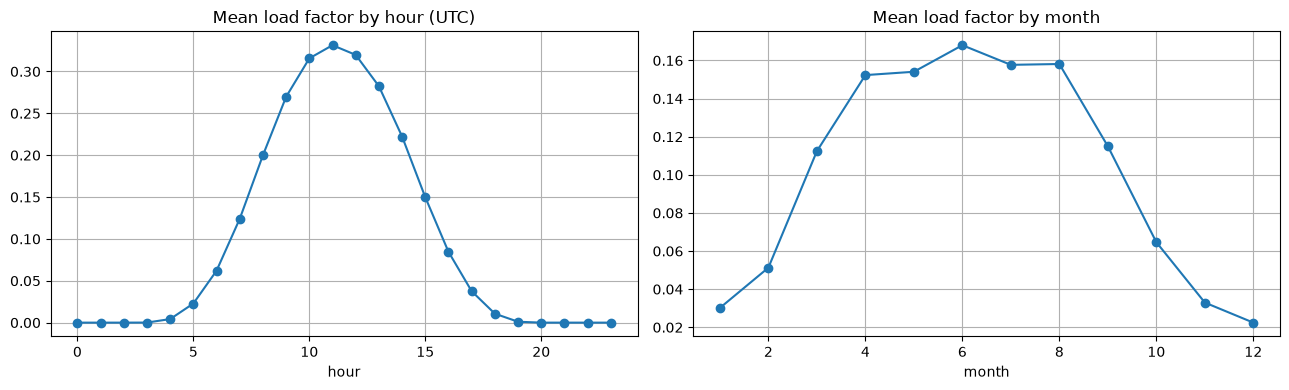

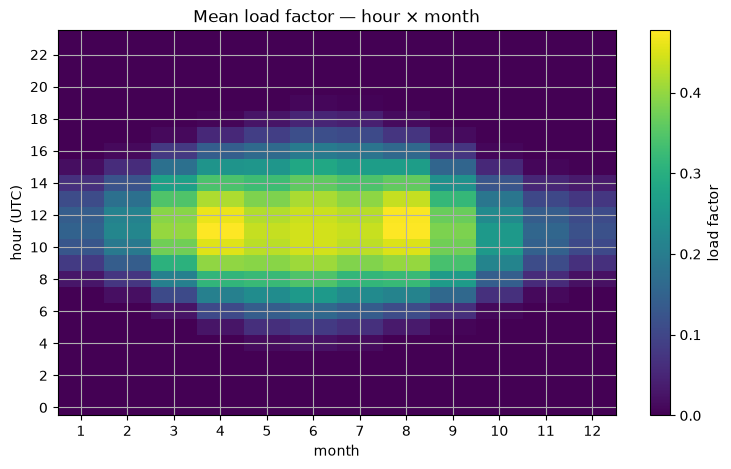

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby(df.index.hour)["load_factor"].mean().plot(ax=ax[0], marker="o", title="Mean load factor by hour (UTC)")
df.groupby(df.index.month)["load_factor"].mean().plot(ax=ax[1], marker="o", title="Mean load factor by month")
ax[0].set_xlabel("hour"); ax[1].set_xlabel("month"); plt.tight_layout(); plt.show()

piv = df.pivot_table(values="load_factor", index=df.index.hour, columns=df.index.month, aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(piv.values, aspect="auto", cmap="viridis", origin="lower")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(0, 24, 2)); ax.set_yticklabels(range(0, 24, 2))
ax.set_xlabel("month"); ax.set_ylabel("hour (UTC)"); ax.set_title("Mean load factor — hour × month")
fig.colorbar(im, ax=ax, label="load factor"); plt.show()

## 6. Daylight vs night
Most of the day is dark in winter. Define a leakage-free daylight proxy from the day-ahead
GHI and see what fraction of hours actually carry signal — these are the rows the model
should be trained and scored on.

In [12]:
ghi_cols = [c for c in df if c.startswith("shortwave_radiation_previous_day1_")]
df["ghi_d1"] = df[ghi_cols].mean(axis=1)           # multi-model mean (skips missing models)
cloud_cols = [c for c in df if c.startswith("cloud_cover_previous_day1_") and df[c].notna().any()]
df["cloud_d1"] = df[cloud_cols].mean(axis=1) if cloud_cols else np.nan
df["is_day"] = df["ghi_d1"] > 5
print(f"daylight hours: {int(df['is_day'].sum()):,} / {len(df):,} ({100*df['is_day'].mean():.0f}%)")
day = df[df["is_day"]].copy()

daylight hours: 10,463 / 21,168 (49%)


## 7. Feature ↔ target relationships
The physics should be visible: generation rises with GHI and falls with cloud. These
scatters tell you which features carry signal and roughly how linear it is.

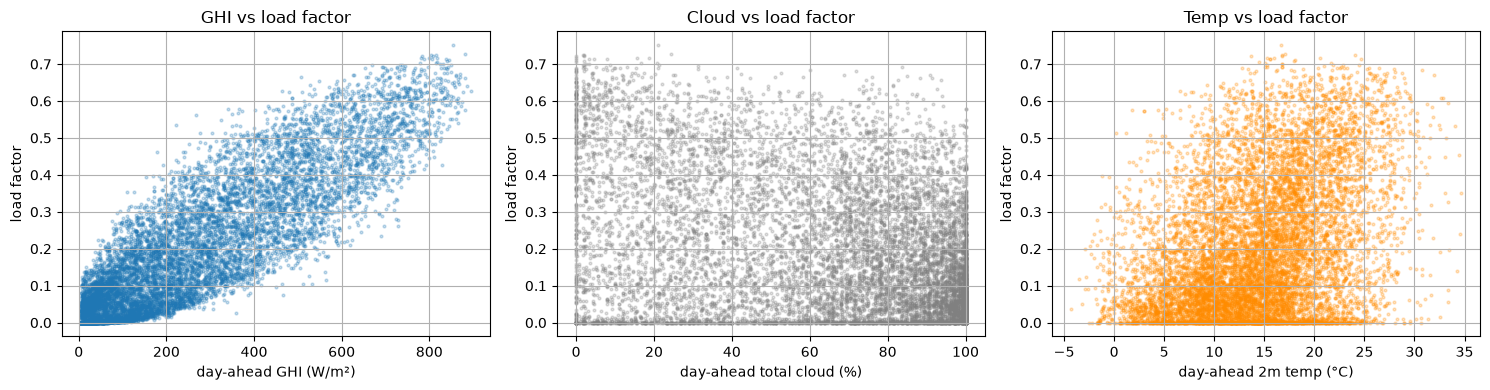

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(day["ghi_d1"], day["load_factor"], s=4, alpha=.25)
ax[0].set(xlabel="day-ahead GHI (W/m²)", ylabel="load factor", title="GHI vs load factor")
if day["cloud_d1"].notna().any():
    ax[1].scatter(day["cloud_d1"], day["load_factor"], s=4, alpha=.25, c="grey")
ax[1].set(xlabel="day-ahead total cloud (%)", ylabel="load factor", title="Cloud vs load factor")
tcol = "temperature_2m_previous_day1_ecmwf"
if tcol in day: ax[2].scatter(day[tcol], day["load_factor"], s=4, alpha=.25, c="darkorange")
ax[2].set(xlabel="day-ahead 2m temp (°C)", ylabel="load factor", title="Temp vs load factor")
plt.tight_layout(); plt.show()

In [ ]:
corr = day.select_dtypes("number").corr()["load_factor"].dropna().sort_values(ascending=False)
print("Top correlations with load_factor (daylight):")
# print(corr.head(15).round(3).to_string()) # to display to 15 top correlations only
print(corr.to_string())   # full ranking, temperature included

Top correlations with load_factor (daylight):
load_factor                                1.000000
measured                                   0.992681
dayaheadforecast                           0.961433
dayaheadconfidence90                       0.930965
dayaheadconfidence10                       0.917091
ghi_d1                                     0.869650
shortwave_radiation_previous_day1_ecmwf    0.867090
shortwave_radiation_previous_day1_icon     0.859934
shortwave_radiation_previous_day2_ecmwf    0.856351
direct_radiation_previous_day1_ecmwf       0.849609
shortwave_radiation_previous_day2_icon     0.843048
direct_radiation_previous_day2_ecmwf       0.838570
direct_radiation_previous_day1_icon        0.811765
shortwave_radiation_previous_day1_gfs      0.810313
direct_radiation_previous_day2_icon        0.791429
shortwave_radiation_previous_day2_gfs      0.790927
direct_radiation_previous_day1_gfs         0.788828
direct_radiation_previous_day2_gfs         0.765777
diffuse_radiation_

## 8. Multi-model agreement
ECMWF / ICON / GFS forecast the same weather. How much they *disagree* (the spread) is your
cheap uncertainty signal. High correlation = they agree; the spread widens on hard days.

Day-ahead GHI correlation between models:
                                         shortwave_radiation_previous_day1_ecmwf  shortwave_radiation_previous_day1_icon  shortwave_radiation_previous_day1_gfs
shortwave_radiation_previous_day1_ecmwf                                    1.000                                   0.945                                  0.898
shortwave_radiation_previous_day1_icon                                     0.945                                   1.000                                  0.897
shortwave_radiation_previous_day1_gfs                                      0.898                                   0.897                                  1.000


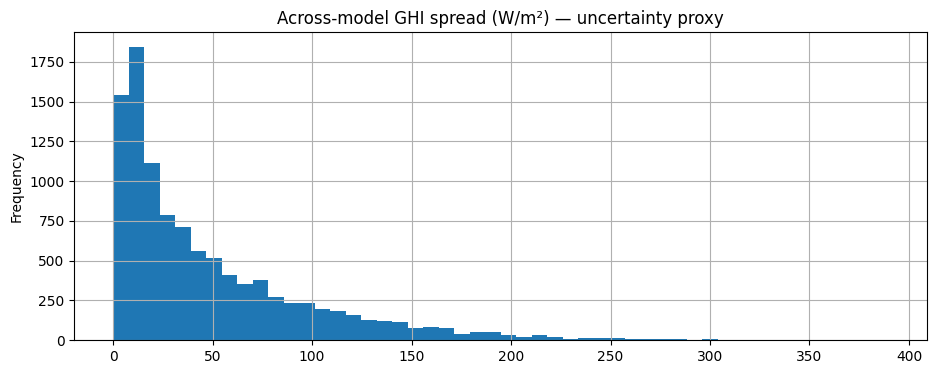

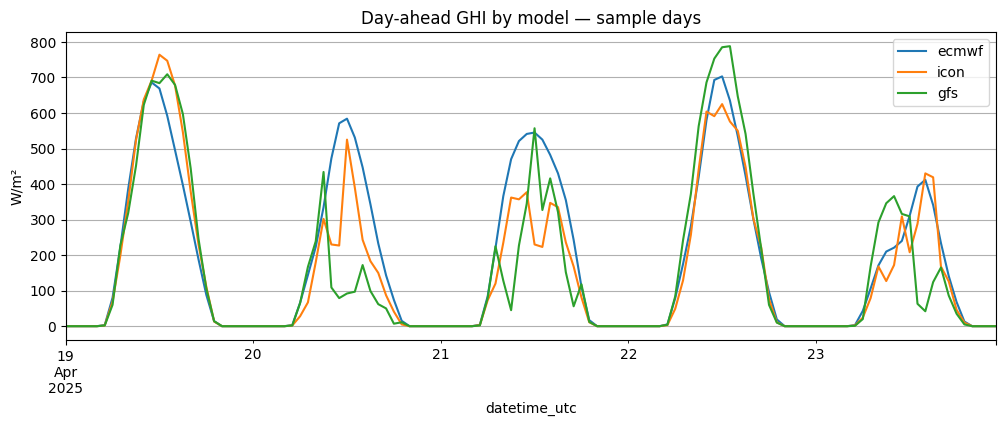

In [15]:
print("Day-ahead GHI correlation between models:")
print(day[ghi_cols].corr().round(3).to_string())
day["ghi_spread"] = day[ghi_cols].std(axis=1)
ax = day["ghi_spread"].plot.hist(bins=50, title="Across-model GHI spread (W/m²) — uncertainty proxy")
plt.show()

# a few example days: do the three models track each other?
sample = df.loc["2025-04-19":"2025-04-23", ghi_cols]
ax = sample.plot(title="Day-ahead GHI by model — sample days", figsize=(12,4))
ax.legend(["ecmwf","icon","gfs"]); ax.set_ylabel("W/m²"); plt.show()

## 9. The bar to beat — Elia's own day-ahead forecast
Elia publishes its operational day-ahead P50 and P10/P90. Quantify its error and the
calibration of its band; this is the benchmark your model must beat.

Elia operational day-ahead (daylight):
  MAE  : 323.9 MW
  Bias : 7.8 MW   (negative = Elia under-forecasts)
  P10–P90 coverage: 0.810   (well-calibrated ~ 0.80)


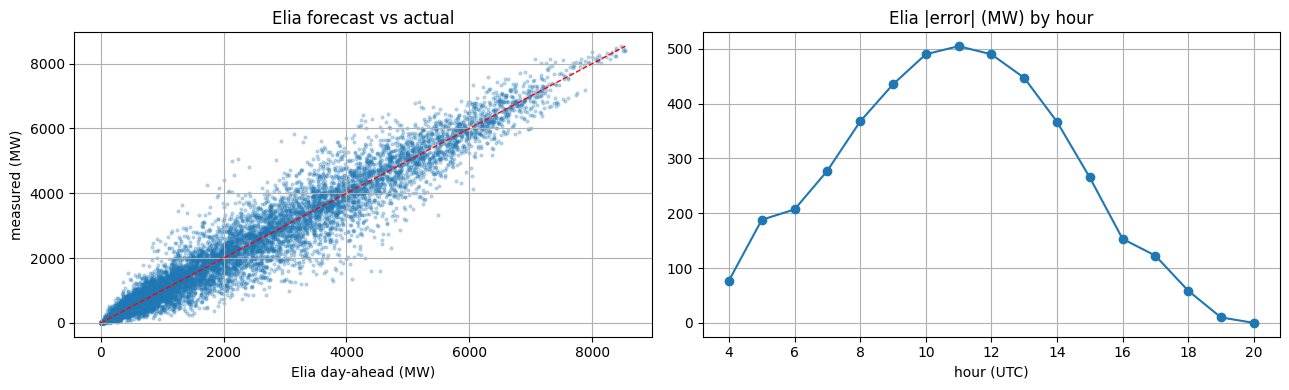

In [16]:
d = day.dropna(subset=["dayaheadforecast"]).copy()
d["elia_err"] = d["measured"] - d["dayaheadforecast"]
print("Elia operational day-ahead (daylight):")
print(f"  MAE  : {d['elia_err'].abs().mean():.1f} MW")
print(f"  Bias : {d['elia_err'].mean():.1f} MW   (negative = Elia under-forecasts)")
cov = ((d["measured"] >= d["dayaheadconfidence10"]) & (d["measured"] <= d["dayaheadconfidence90"])).mean()
print(f"  P10–P90 coverage: {cov:.3f}   (well-calibrated ~ 0.80)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(d["dayaheadforecast"], d["measured"], s=4, alpha=.25)
lim = [0, max(d['measured'].max(), d['dayaheadforecast'].max())]
ax[0].plot(lim, lim, "r--", lw=1); ax[0].set(xlabel="Elia day-ahead (MW)", ylabel="measured (MW)", title="Elia forecast vs actual")
d.groupby(d.index.hour)["elia_err"].apply(lambda s: s.abs().mean()).plot(ax=ax[1], marker="o", title="Elia |error| (MW) by hour")
ax[1].set_xlabel("hour (UTC)"); plt.tight_layout(); plt.show()

## 10. Persistence & the value of lag features
How correlated is a slot with the *same slot* a day / week earlier? Strong, slowly-decaying
correlation means a persistence baseline is hard to beat and the `lag_1d` / `lag_7d` features
carry real signal. (Computed on daylight rows to avoid the trivial night zeros.)

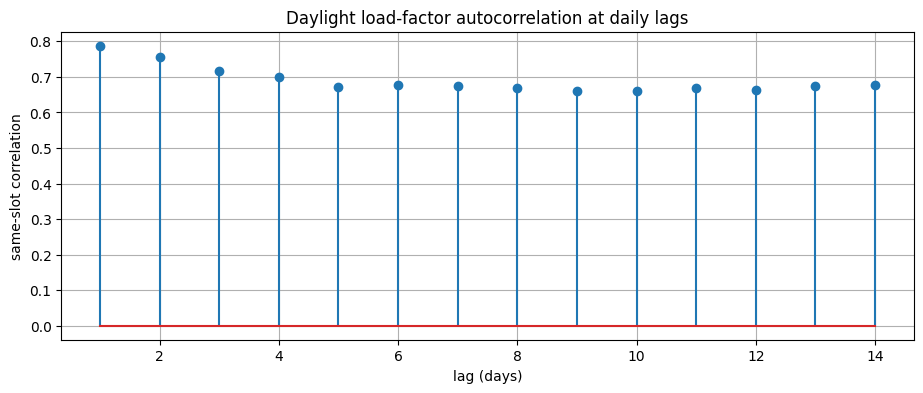

corr with yesterday (1d): 0.788 | last week (7d): 0.674


In [17]:
lf = df["load_factor"]
lags_days = list(range(1, 15))
ac = []
for L in lags_days:
    sh = df["load_factor"].shift(freq=f"{L}D").rename("lagged")
    j = df.loc[df["is_day"], ["load_factor"]].join(sh).dropna()   # join aligns shifted index
    ac.append(j["load_factor"].corr(j["lagged"]))
plt.figure(); plt.stem(lags_days, ac)
plt.xlabel("lag (days)"); plt.ylabel("same-slot correlation")
plt.title("Daylight load-factor autocorrelation at daily lags"); plt.show()
print("corr with yesterday (1d):", round(ac[0], 3), "| last week (7d):", round(ac[6], 3))

## 11. Clear-sky index — the workhorse normalization
Clear-sky index = forecast GHI ÷ clear-sky GHI. It strips out the deterministic sun-geometry
(time-of-day, season) and leaves the part driven by *weather* (clouds). A clean cluster near
~1.0 (clear skies) with a tail toward 0 (overcast) means the normalization behaves, and the
index should track load factor even more tightly than raw GHI.

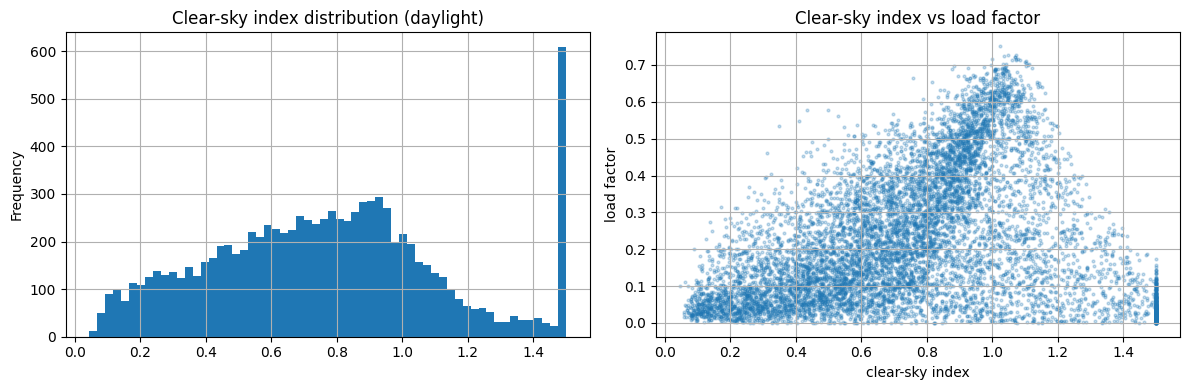

clear-sky index median (daylight): 0.761


In [18]:
import pvlib
loc = pvlib.location.Location(50.85, 4.35, tz="UTC")
df["cs_ghi"] = loc.get_clearsky(df.index)["ghi"]
df["csi_d1"] = (df["ghi_d1"] / df["cs_ghi"]).replace([np.inf, -np.inf], np.nan)
dd = df[df["is_day"] & df["cs_ghi"].gt(20)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dd["csi_d1"].clip(0, 1.5).plot.hist(bins=60, ax=ax[0]); ax[0].set_title("Clear-sky index distribution (daylight)")
ax[1].scatter(dd["csi_d1"].clip(0, 1.5), dd["load_factor"], s=4, alpha=.25)
ax[1].set(xlabel="clear-sky index", ylabel="load factor", title="Clear-sky index vs load factor")
plt.tight_layout(); plt.show()
print("clear-sky index median (daylight):", round(dd["csi_d1"].median(), 3))

## 12. Does model disagreement predict error? (the uncertainty signal)
If the across-model GHI **spread** is larger on days the forecast is more wrong, then spread is
a usable predictor of uncertainty — which justifies feeding it to the model and underpins the
probabilistic P10/P90 bands. We use Elia's own forecast error here as the stand-in for "how
hard was this day".

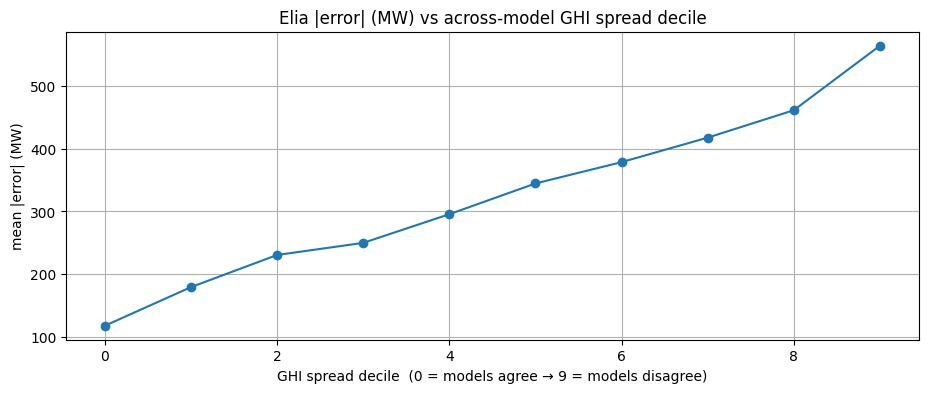

corr(spread, |error|): 0.331


In [19]:
d = df[df["is_day"]].dropna(subset=["dayaheadforecast"]).copy()
d["ghi_spread"] = df[ghi_cols].std(axis=1)
d["abs_err"] = (d["measured"] - d["dayaheadforecast"]).abs()
d["spread_decile"] = pd.qcut(d["ghi_spread"], 10, labels=False, duplicates="drop")
g = d.groupby("spread_decile")["abs_err"].mean()
ax = g.plot(marker="o", title="Elia |error| (MW) vs across-model GHI spread decile")
ax.set_xlabel("GHI spread decile  (0 = models agree → 9 = models disagree)")
ax.set_ylabel("mean |error| (MW)"); plt.show()
print("corr(spread, |error|):", round(d["ghi_spread"].corr(d["abs_err"]), 3))

## 13. Physical plausibility / outlier checks
Cheap sanity checks that catch data problems before they reach the model. Small non-zero
counts are usually fine (twilight, measurement noise); large ones deserve a look.

In [20]:
checks = {
    "load_factor > 1":                          int((df["load_factor"] > 1).sum()),
    "load_factor < 0":                          int((df["load_factor"] < 0).sum()),
    "generation>0 while dark (ghi_d1<=5)":      int(((df["load_factor"] > 0.01) & (df["ghi_d1"] <= 5)).sum()),
    "forecast GHI>50 but measured==0 (daytime)":int(((df["ghi_d1"] > 50) & (df["measured"] == 0)).sum()),
    "capacity jump >1% between hours":          int((df["monitoredcapacity"].pct_change().abs() > 0.01).sum()),
}
for k, v in checks.items():
    print(f"  {k:48s}: {v}")

  load_factor > 1                                 : 0
  load_factor < 0                                 : 0
  generation>0 while dark (ghi_d1<=5)             : 505
  forecast GHI>50 but measured==0 (daytime)       : 0
  capacity jump >1% between hours                 : 8


## 14. What the data is telling us (preprocessing implications)

Summarise here *after* reading the plots above. Typical conclusions to verify against your
own run:

- **Dead columns:** the layered `cloud_cover_low/mid/high_*` columns are fully empty (solid red
  stripes in §2, confirmed in §1b) → **drop** (18 columns). Keep the six **total** cloud columns
  `cloud_cover_previous_day{1,2}_{ecmwf,icon,gfs}`.
- **Start-up gap:** weather is missing only at the **start** of 2024 (left red block, §2/§2.4),
  not scattered → candidate to **trim the start date** rather than impute.
- **Target intact:** `measured` / `load_factor` / `dayaheadforecast` have no gaps (§3) → the
  thing we predict and the baseline are safe across the whole span.
- **Normalize, don't fight capacity drift** (§4) → predict load factor, confirm capacity series.
- **Night carries no signal** (§3, §6) → daylight masking belongs in the feature step.
- **Multi-model spread is real** (§8) → keep all three models for the uncertainty feature.
- **The target to beat** is Elia's MAE / bias / coverage (§9).

> These are *observations*, not actions. The actual trimming/dropping happens in a separate
> cleaning step so this diagnostic notebook stays reproducible and unmodified.
